In [2]:
#Importing necessary libraries
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font='DejaVu Sans')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13, 'axes.labelsize': 11})

In [3]:
#Data Acquisition and Cleaning
import os
import time
from dotenv import load_dotenv
from concurrent.futures import ThreadPoolExecutor, as_completed

load_dotenv(dotenv_path="/home/bruvisrekt/Desktop/projs/urban_pollutant_exposure/.env")
API_KEY = os.environ['OPENAQ_API_KEY']
HEADERS = {'X-API-Key': API_KEY}

# Step 1: find US locations that measure PM2.5 (parameter id 2)
LOCATIONS_URL = 'https://api.openaq.org/v3/locations'
loc_params = {
    'parameters_id': 2,
    'countries_id': 155,   # United States
    'limit': 1000,
    'page': 1,
}

locations = []
while True:
    resp = requests.get(LOCATIONS_URL, params=loc_params, headers=HEADERS)
    resp.raise_for_status()
    results = resp.json()['results']
    if not results:
        break
    locations.extend(results)
    if len(results) < loc_params['limit']:
        break
    loc_params['page'] += 1
    time.sleep(0.2)

print(f'Locations found: {len(locations):,}')

# Step 2: fetch each station's PM2.5 daily measurements, in parallel
def fetch_station_measurements(loc):
    pm25_sensor = next(
        (s for s in loc.get('sensors', []) if s['parameter']['id'] == 2),
        None
    )
    if pm25_sensor is None:
        return []

    sensor_id = pm25_sensor['id']
    meas_url = f'https://api.openaq.org/v3/sensors/{sensor_id}/days'
    meas_params = {
        'date_from': '2023-01-01',
        'date_to': '2024-01-01',
        'limit': 1000,
    }
    try:
        resp = requests.get(meas_url, params=meas_params, headers=HEADERS)
        resp.raise_for_status()
    except requests.exceptions.RequestException:
        return []

    return [{
        'locationId': loc['id'],
        'location': loc['name'],
        'latitude': loc['coordinates']['latitude'] if loc.get('coordinates') else None,
        'longitude': loc['coordinates']['longitude'] if loc.get('coordinates') else None,
        'timestamp': m['period']['datetimeFrom']['utc'],
        'value': m['value'],
    } for m in resp.json().get('results', [])]

records = []
with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {executor.submit(fetch_station_measurements, loc): loc for loc in locations}
    for i, future in enumerate(as_completed(futures), start=1):
        records.extend(future.result())
        if i % 100 == 0 or i == len(locations):
            print(f'Processed {i:,}/{len(locations):,} | records: {len(records):,}')

raw_aq = pd.DataFrame(records)
print(f'\nDone. Measurement records collected: {len(raw_aq):,}')

Locations found: 5,780
Processed 100/5,780 | records: 21,099
Processed 200/5,780 | records: 22,665
Processed 300/5,780 | records: 22,665
Processed 400/5,780 | records: 22,665
Processed 500/5,780 | records: 22,665
Processed 600/5,780 | records: 22,665
Processed 700/5,780 | records: 22,665
Processed 800/5,780 | records: 22,665
Processed 900/5,780 | records: 22,665
Processed 1,000/5,780 | records: 22,665
Processed 1,100/5,780 | records: 22,665
Processed 1,200/5,780 | records: 22,665
Processed 1,300/5,780 | records: 24,307
Processed 1,400/5,780 | records: 24,307
Processed 1,500/5,780 | records: 24,307
Processed 1,600/5,780 | records: 24,307
Processed 1,700/5,780 | records: 24,307
Processed 1,800/5,780 | records: 24,307
Processed 1,900/5,780 | records: 24,307
Processed 2,000/5,780 | records: 24,307
Processed 2,100/5,780 | records: 24,307
Processed 2,200/5,780 | records: 24,307
Processed 2,300/5,780 | records: 24,307
Processed 2,400/5,780 | records: 31,875
Processed 2,500/5,780 | records: 31

In [5]:
aq_df = raw_aq.rename(columns={'value': 'pm25_ug_m3'}).copy()
print(f'aq_df shape: {aq_df.shape}')
aq_df.head()

aq_df shape: (31875, 6)


,locationId,location,latitude,longitude,timestamp,pm25_ug_m3
0,162,Houston Deer Park C3,29.670025,-95.128508,2023-01-01T06:00:00Z,15.80
1,162,Houston Deer Park C3,29.670025,-95.128508,2023-01-02T06:00:00Z,8.83
2,162,Houston Deer Park C3,29.670025,-95.128508,2023-01-03T06:00:00Z,12.50
3,162,Houston Deer Park C3,29.670025,-95.128508,2023-01-04T06:00:00Z,7.04
4,162,Houston Deer Park C3,29.670025,-95.128508,2023-01-05T06:00:00Z,10.00


In [6]:
aq_df = aq_df[aq_df['pm25_ug_m3'] >= 0]
aq_df = aq_df[aq_df['pm25_ug_m3'] <= 500]

print(f'AQ records after cleaning : {len(aq_df):,}')

AQ records after cleaning : 31,867


In [7]:
census_df = pd.read_csv('acs_median_income_by_zip.csv', dtype={'zip_code': str})

census_df.rename(columns={
    'zip_code':                'zip_code',
    'median_household_income': 'median_income_usd'
}, inplace=True)

census_df.dropna(subset=['median_income_usd'], inplace=True)
census_df['zip_code'] = census_df['zip_code'].str.zfill(5)
census_df = census_df[census_df['median_income_usd'] > 0]

print(f'ZIP codes in Census data  : {len(census_df):,}')

ZIP codes in Census data  : 30,621


In [9]:
#Data Integration
geolocator = Nominatim(user_agent='urban_pollution_study_v1')
geocode    = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def get_zip(lat, lon):
    try:
        location = geocode(f'{lat}, {lon}', exactly_one=True, language='en')
        if location and 'postcode' in location.raw.get('address', {}):
            return str(location.raw['address']['postcode']).zfill(5)[:5]
    except Exception:
        pass
    return None

unique_sensors = aq_df[['locationId', 'latitude', 'longitude']].drop_duplicates()
print(f'Unique locations to geocode: {len(unique_sensors):,}')

zip_codes = []
total = len(unique_sensors)
for i, row in enumerate(unique_sensors.itertuples(), start=1):
    zip_codes.append(get_zip(row.latitude, row.longitude))
    if i % 25 == 0 or i == total:
        print(f'Geocoded {i:,}/{total:,}')

unique_sensors['zip_code'] = zip_codes

aq_df = aq_df.merge(unique_sensors[['locationId', 'zip_code']], on='locationId', how='left')

print(f'\nDone. Locations successfully geocoded: {unique_sensors["zip_code"].notna().sum()}/{total}')

Unique locations to geocode: 142
Geocoded 25/142
Geocoded 50/142
Geocoded 75/142
Geocoded 100/142


RateLimiter caught an error, retrying (0/2 tries). Called with (*('41.06222759157342, -74.86309808230175',), **{'exactly_one': True, 'language': 'en'}).
Traceback (most recent call last):
  File "/home/bruvisrekt/Desktop/projs/venv/lib/python3.13/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
  File "/home/bruvisrekt/Desktop/projs/venv/lib/python3.13/site-packages/urllib3/connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
  File "/usr/lib/python3.13/http/client.py", line 1459, in getresponse
    response.begin()
    ~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/http/client.py", line 336, in begin
    version, status, reason = self._read_status()
                              ~~~~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/http/client.py", line 297, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "/usr/lib/python3.13/

Geocoded 125/142
Geocoded 142/142

Done. Locations successfully geocoded: 134/142


In [12]:
zip_agg = (
    aq_df.groupby('zip_code')['pm25_ug_m3']
    .agg(mean_pm25='mean', sensor_count='count', std_pm25='std')
    .reset_index()
)

unified_df = zip_agg.merge(
    census_df[['zip_code', 'median_income_usd']],
    on='zip_code',
    how='inner'
)

unified_df['income_quintile'] = pd.qcut(
    unified_df['median_income_usd'],
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

unified_df.dropna(subset=['mean_pm25', 'median_income_usd'], inplace=True)
unified_df.reset_index(drop=True, inplace=True)

unified_df.to_csv('unified_pollution_income.csv', index=False)

print(unified_df[['zip_code', 'mean_pm25', 'median_income_usd', 'income_quintile']].head(10).to_string())
print(f'\nFinal unified dataset shape: {unified_df.shape}')

  zip_code  mean_pm25  median_income_usd  income_quintile
0    01022   7.269597              52207                1
1    01730  10.411353             143424                5
2    01773   7.686394             185288                5
3    01832   7.669138              78151                3
4    01905   6.889405              74792                3
5    02119   7.507156              37158                1
6    02125   8.120500              64983                2
7    02144  10.788338             133627                5
8    02169   0.644500              86335                4
9    02302   7.466500              80702                3

Final unified dataset shape: (121, 6)


In [13]:
#Statistical Analysis
r, p_pearson = stats.pearsonr(unified_df['median_income_usd'], unified_df['mean_pm25'])

print('─' * 45)
print('  Pearson Correlation Analysis')
print('─' * 45)
print(f'  Correlation Coefficient (r) : {r:.4f}')
print(f'  p-value                     : {p_pearson:.4e}')
print(f'  Interpretation              : {"Statistically significant" if p_pearson < 0.05 else "Not significant"} (α = 0.05)')
print('─' * 45)

─────────────────────────────────────────────
  Pearson Correlation Analysis
─────────────────────────────────────────────
  Correlation Coefficient (r) : -0.0345
  p-value                     : 7.0700e-01
  Interpretation              : Not significant (α = 0.05)
─────────────────────────────────────────────


In [14]:
quintile_groups = [
    unified_df[unified_df['income_quintile'] == q]['mean_pm25'].dropna()
    for q in range(1, 6)
]

f_stat, p_anova = stats.f_oneway(*quintile_groups)

print('─' * 45)
print('  One-Way ANOVA')
print('─' * 45)
print(f'  F-Statistic : {f_stat:.4f}')
print(f'  p-value     : {p_anova:.4e}')
print(f'  Result      : {"Significant difference across quintiles" if p_anova < 0.05 else "No significant difference"}')
print('─' * 45)

─────────────────────────────────────────────
  One-Way ANOVA
─────────────────────────────────────────────
  F-Statistic : 0.4903
  p-value     : 7.4286e-01
  Result      : No significant difference
─────────────────────────────────────────────


In [15]:
summary = unified_df.groupby('income_quintile').agg(
    Mean_PM25=('mean_pm25', 'mean'),
    Median_PM25=('mean_pm25', 'median'),
    Std_PM25=('mean_pm25', 'std'),
    Mean_Income=('median_income_usd', 'mean'),
    ZIP_Count=('zip_code', 'count')
).round(2)

print('\nDescriptive Statistics by Income Quintile\n')
print(summary.to_string())


Descriptive Statistics by Income Quintile

                 Mean_PM25  Median_PM25  Std_PM25  Mean_Income  ZIP_Count
income_quintile                                                          
1                    10.34        10.10      1.92     41953.44         25
2                     9.58         9.27      3.19     60296.17         24
3                     9.60         8.92      3.35     74107.71         24
4                    10.50        10.37      5.31     90823.08         24
5                     9.27         9.08      4.07    131031.75         24


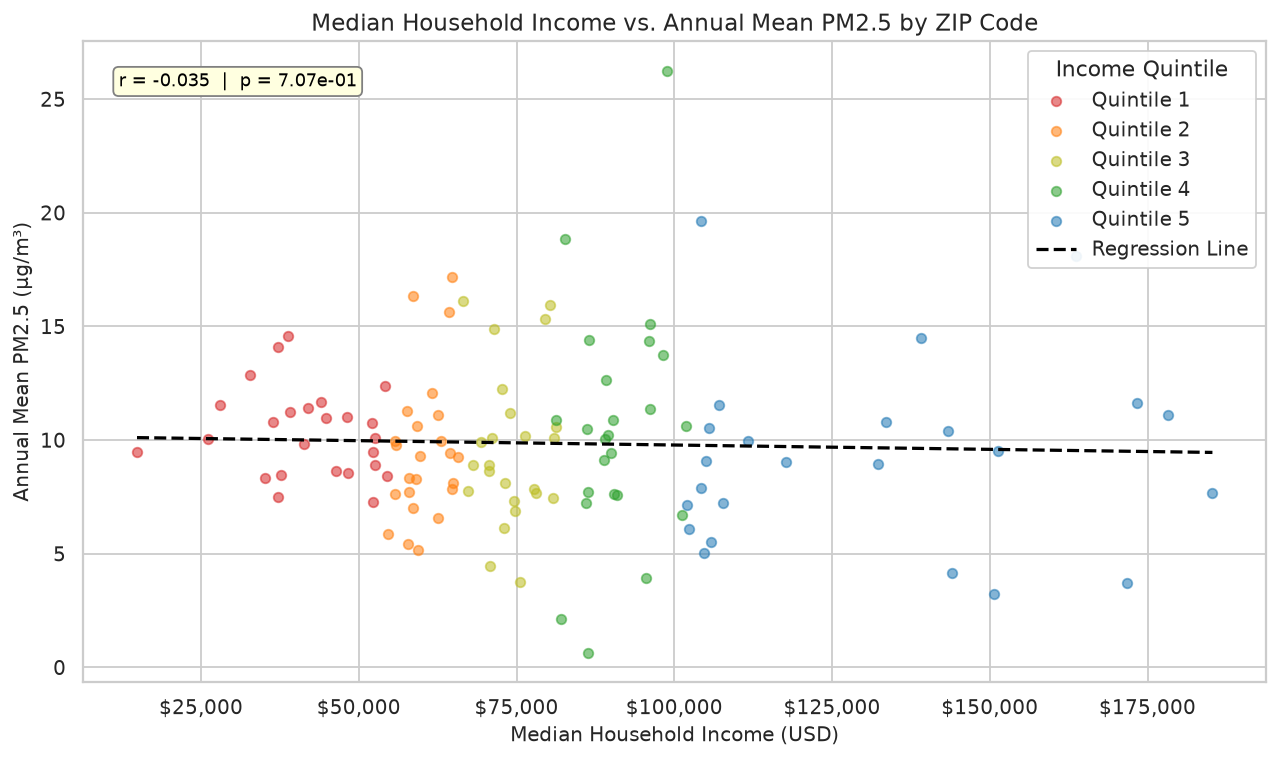

In [17]:
#Visualization & Results
#Scatter Plot : Income vs Mean PM2.5
bar_colors = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']
quintile_palette = dict(zip(range(1, 6), bar_colors))

fig, ax = plt.subplots(figsize=(10, 6))

for q in range(1, 6):
    subset = unified_df[unified_df['income_quintile'] == q]
    ax.scatter(
        subset['median_income_usd'],
        subset['mean_pm25'],
        c=quintile_palette[q],
        alpha=0.55,
        s=28,
        label=f'Quintile {q}'
    )

m, b = np.polyfit(unified_df['median_income_usd'], unified_df['mean_pm25'], 1)
x_line = np.linspace(unified_df['median_income_usd'].min(), unified_df['median_income_usd'].max(), 300)
ax.plot(x_line, m * x_line + b, color='black', linewidth=1.8, linestyle='--', label='Regression Line')

ax.set_xlabel('Median Household Income (USD)')
ax.set_ylabel('Annual Mean PM2.5 (µg/m³)')
ax.set_title('Median Household Income vs. Annual Mean PM2.5 by ZIP Code')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Income Quintile', framealpha=0.9)
ax.annotate(
    f'r = {r:.3f}  |  p = {p_pearson:.2e}',
    xy=(0.03, 0.93), xycoords='axes fraction',
    fontsize=10, color='black',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray')
)

plt.tight_layout()
plt.savefig('outputs/fig1_scatter_regression.png', bbox_inches='tight')
plt.show()

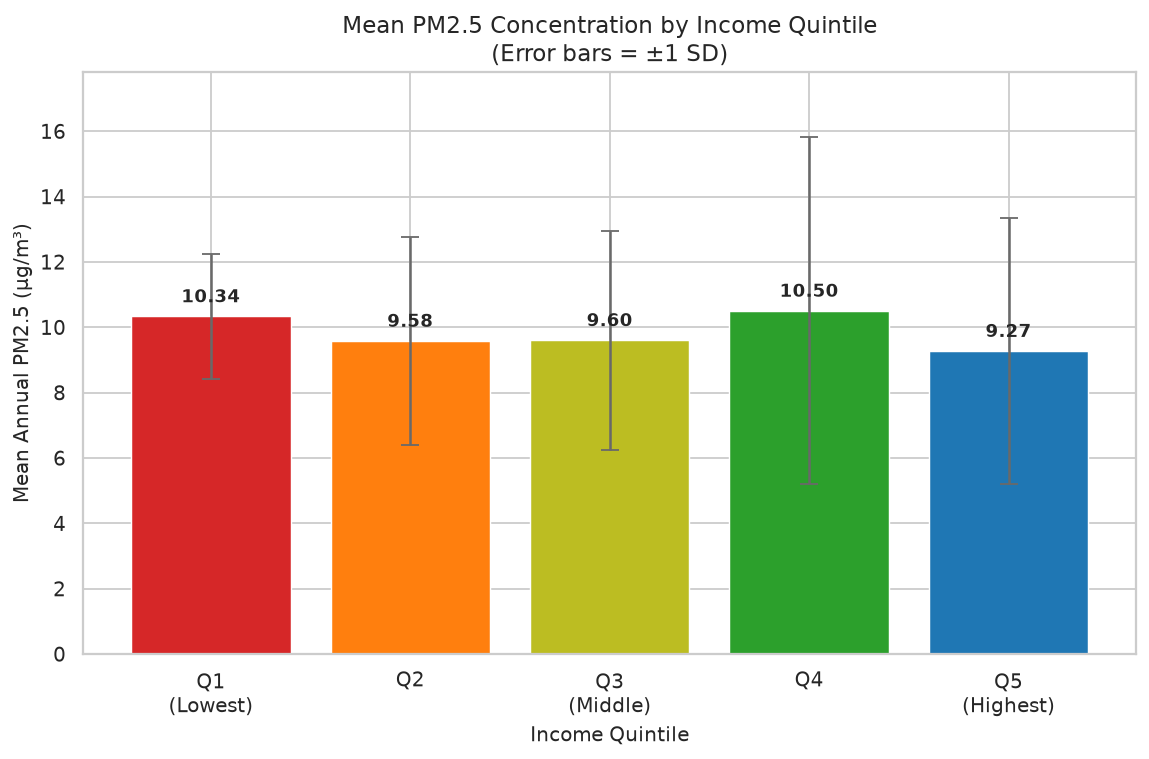

In [18]:
#Bar Plot : Mean PM2.5 by Income Quintile
quintile_stats = unified_df.groupby('income_quintile').agg(
    mean_pm25=('mean_pm25', 'mean'),
    std_pm25=('mean_pm25', 'std')
).reset_index()

quintile_labels = ['Q1\n(Lowest)', 'Q2', 'Q3\n(Middle)', 'Q4', 'Q5\n(Highest)']

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    quintile_labels,
    quintile_stats['mean_pm25'],
    yerr=quintile_stats['std_pm25'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8,
    capsize=5,
    error_kw={'elinewidth': 1.4, 'ecolor': 'dimgray'}
)

for bar, val in zip(bars, quintile_stats['mean_pm25']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.2f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_xlabel('Income Quintile')
ax.set_ylabel('Mean Annual PM2.5 (µg/m³)')
ax.set_title('Mean PM2.5 Concentration by Income Quintile\n(Error bars = ±1 SD)')
ax.set_ylim(0, quintile_stats['mean_pm25'].max() + quintile_stats['std_pm25'].max() + 2)

plt.tight_layout()
plt.savefig('outputs/fig2_bar_quintile.png', bbox_inches='tight')
plt.show()

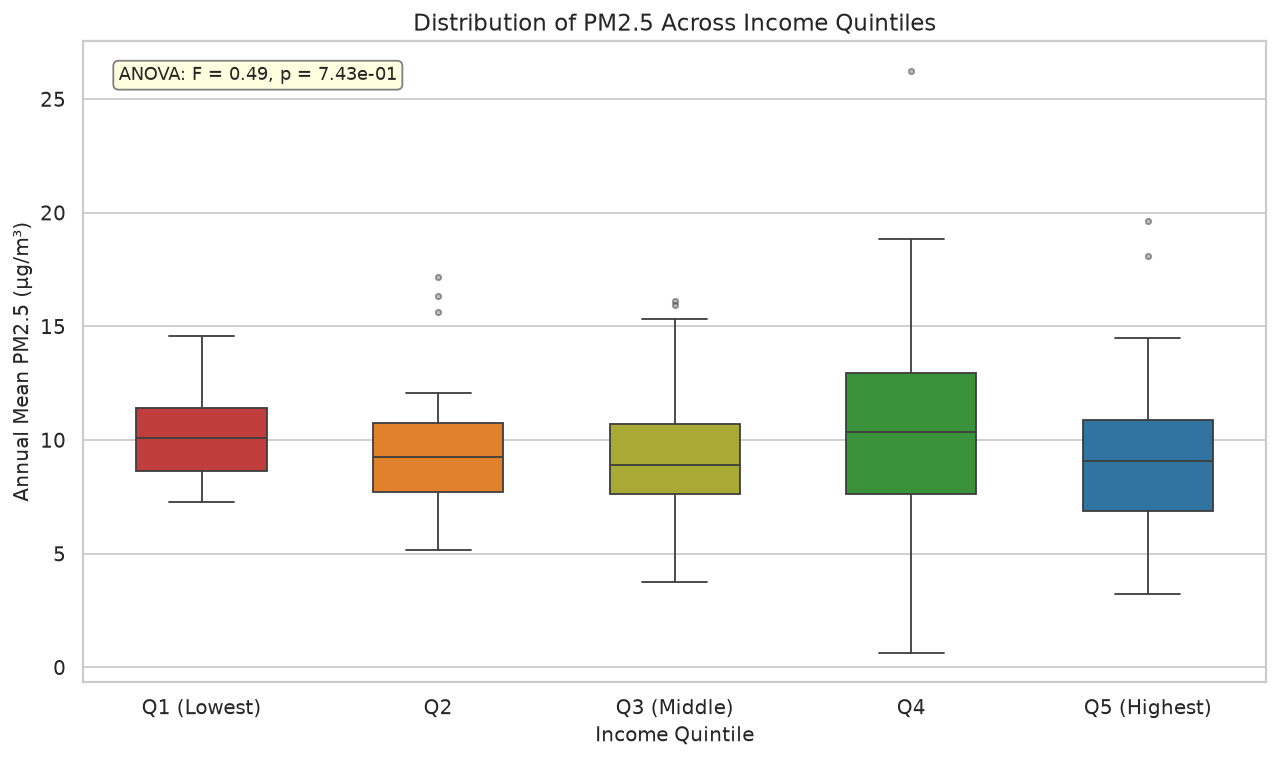

In [19]:
#Box Plot : PM2.5 Distribution by Income Quintile
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=unified_df,
    x='income_quintile',
    y='mean_pm25',
    palette=bar_colors,
    width=0.55,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5),
    ax=ax
)

ax.set_xticklabels(['Q1 (Lowest)', 'Q2', 'Q3 (Middle)', 'Q4', 'Q5 (Highest)'])
ax.set_xlabel('Income Quintile')
ax.set_ylabel('Annual Mean PM2.5 (µg/m³)')
ax.set_title('Distribution of PM2.5 Across Income Quintiles')
ax.annotate(
    f'ANOVA: F = {f_stat:.2f}, p = {p_anova:.2e}',
    xy=(0.03, 0.94), xycoords='axes fraction',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray')
)

plt.tight_layout()
plt.savefig('outputs/fig3_boxplot_quintile.png', bbox_inches='tight')
plt.show()

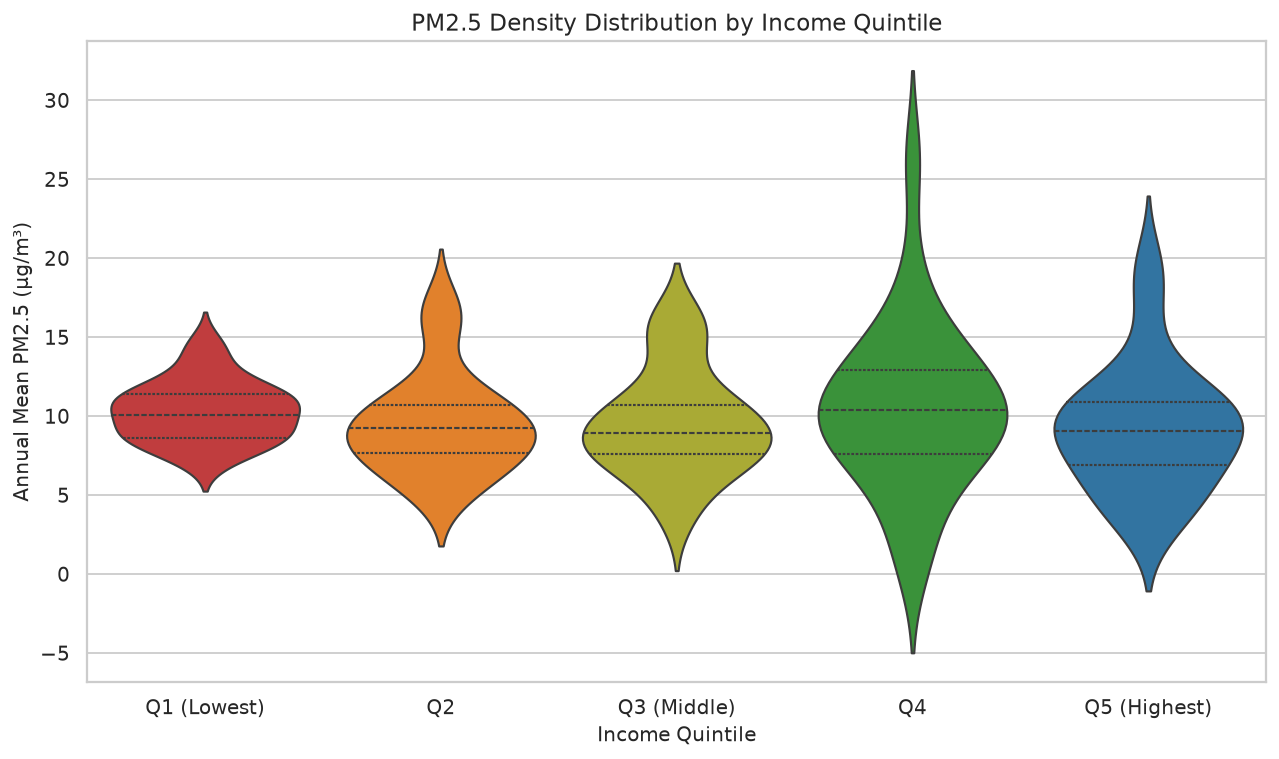

In [20]:
#Violin Plot : PM2.5 Density by Income Quintile
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=unified_df,
    x='income_quintile',
    y='mean_pm25',
    palette=bar_colors,
    inner='quartile',
    linewidth=1.2,
    ax=ax
)

ax.set_xticklabels(['Q1 (Lowest)', 'Q2', 'Q3 (Middle)', 'Q4', 'Q5 (Highest)'])
ax.set_xlabel('Income Quintile')
ax.set_ylabel('Annual Mean PM2.5 (µg/m³)')
ax.set_title('PM2.5 Density Distribution by Income Quintile')

plt.tight_layout()
plt.savefig('outputs/fig4_violin_quintile.png', bbox_inches='tight')
plt.show()

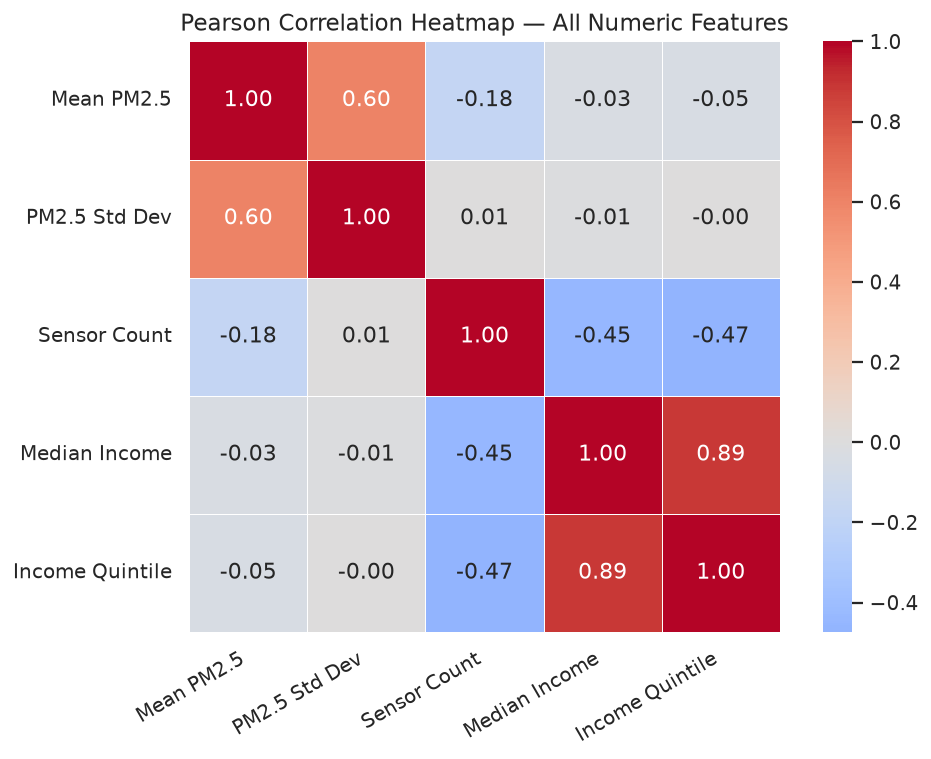

In [21]:
#Correlation Heatmap : All Numeric Features
numeric_cols = ['mean_pm25', 'std_pm25', 'sensor_count', 'median_income_usd', 'income_quintile']
corr_matrix = unified_df[numeric_cols].corr()

readable_labels = ['Mean PM2.5', 'PM2.5 Std Dev', 'Sensor Count', 'Median Income', 'Income Quintile']

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    xticklabels=readable_labels,
    yticklabels=readable_labels,
    ax=ax
)

ax.set_title('Pearson Correlation Heatmap — All Numeric Features')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('outputs/fig5_correlation_heatmap.png', bbox_inches='tight')
plt.show()

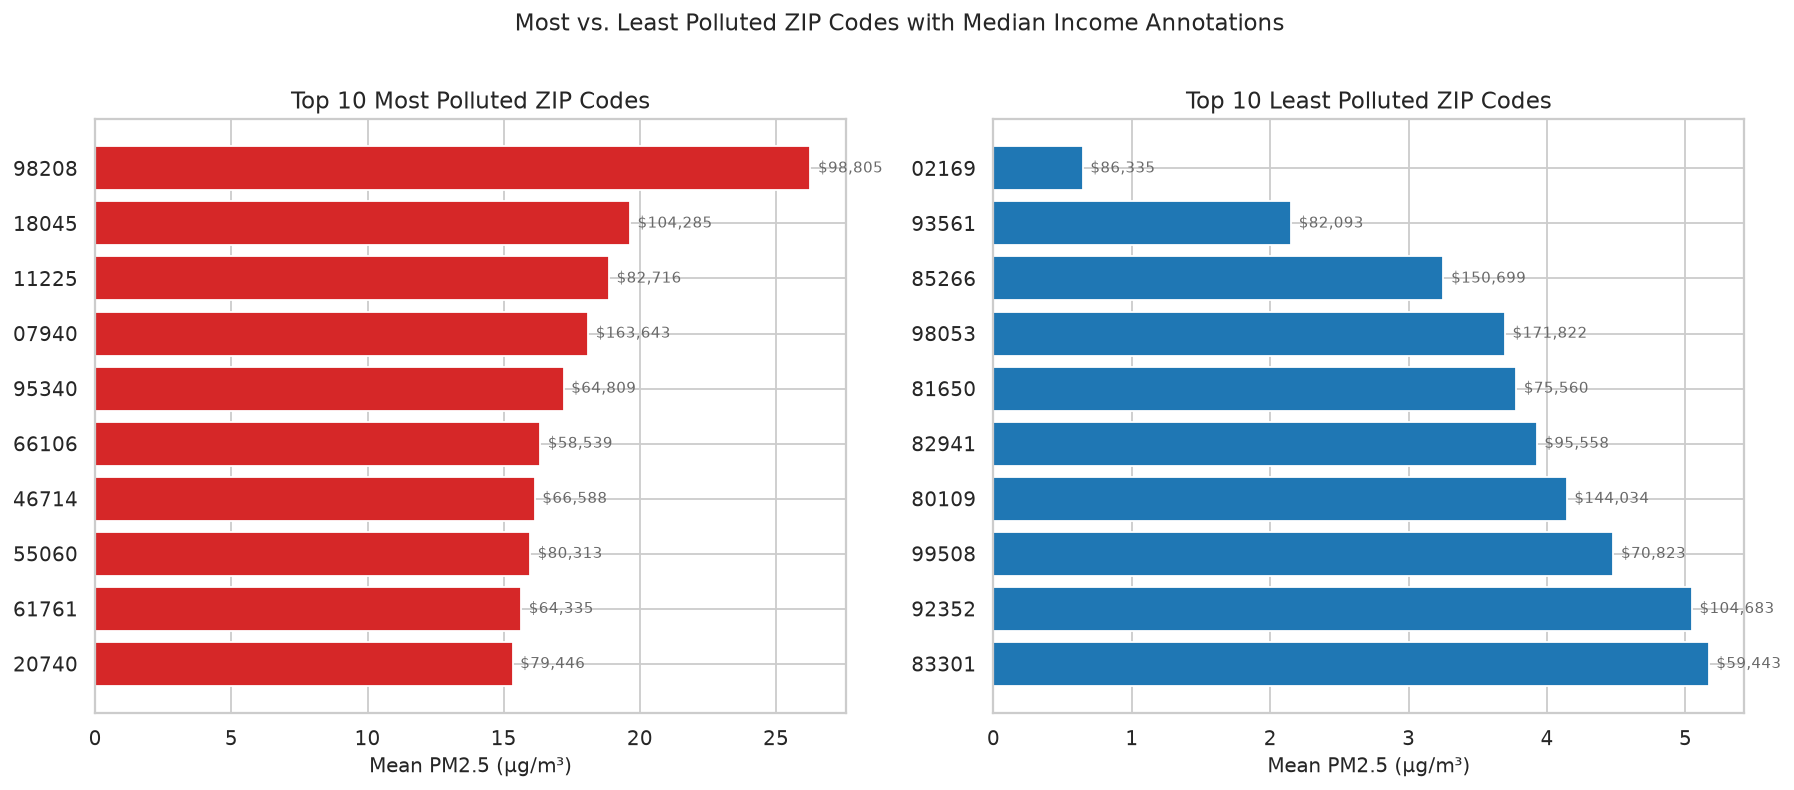

In [22]:
#Top 10 Most vs. Least Polluted ZIP Codes with Income Annotations
top10_high = unified_df.nlargest(10, 'mean_pm25')[['zip_code', 'mean_pm25', 'median_income_usd']]
top10_low  = unified_df.nsmallest(10, 'mean_pm25')[['zip_code', 'mean_pm25', 'median_income_usd']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top10_high['zip_code'].astype(str), top10_high['mean_pm25'], color='#d62728', edgecolor='white')
axes[0].set_xlabel('Mean PM2.5 (µg/m³)')
axes[0].set_title('Top 10 Most Polluted ZIP Codes')
axes[0].invert_yaxis()
for i, (pm, inc) in enumerate(zip(top10_high['mean_pm25'], top10_high['median_income_usd'])):
    axes[0].text(pm + 0.1, i, f' ${inc:,.0f}', va='center', fontsize=8.5, color='dimgray')

axes[1].barh(top10_low['zip_code'].astype(str), top10_low['mean_pm25'], color='#1f77b4', edgecolor='white')
axes[1].set_xlabel('Mean PM2.5 (µg/m³)')
axes[1].set_title('Top 10 Least Polluted ZIP Codes')
axes[1].invert_yaxis()
for i, (pm, inc) in enumerate(zip(top10_low['mean_pm25'], top10_low['median_income_usd'])):
    axes[1].text(pm + 0.02, i, f' ${inc:,.0f}', va='center', fontsize=8.5, color='dimgray')

fig.suptitle('Most vs. Least Polluted ZIP Codes with Median Income Annotations', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig6_top10_comparison.png', bbox_inches='tight')
plt.show()

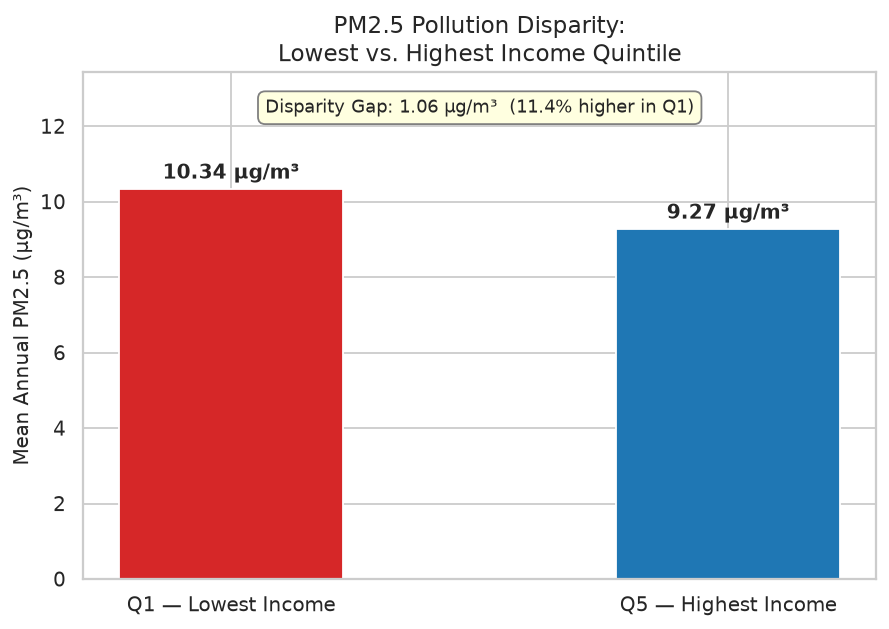

Q1 Mean PM2.5 : 10.336 µg/m³
Q5 Mean PM2.5 : 9.274 µg/m³
Absolute Gap  : 1.061 µg/m³
Relative Gap  : 11.4%


In [23]:
#Disparity Gap Analysis : Q1 vs. Q5
q1_mean = unified_df[unified_df['income_quintile'] == 1]['mean_pm25'].mean()
q5_mean = unified_df[unified_df['income_quintile'] == 5]['mean_pm25'].mean()
gap_abs = q1_mean - q5_mean
gap_pct = (gap_abs / q5_mean) * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ['Q1 — Lowest Income', 'Q5 — Highest Income'],
    [q1_mean, q5_mean],
    color=['#d62728', '#1f77b4'],
    width=0.45,
    edgecolor='white'
)

for bar, val in zip(bars, [q1_mean, q5_mean]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f'{val:.2f} µg/m³',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.annotate(
    f'Disparity Gap: {gap_abs:.2f} µg/m³  ({gap_pct:.1f}% higher in Q1)',
    xy=(0.5, 0.92), xycoords='axes fraction', ha='center',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray')
)

ax.set_ylabel('Mean Annual PM2.5 (µg/m³)')
ax.set_title('PM2.5 Pollution Disparity:\nLowest vs. Highest Income Quintile')
ax.set_ylim(0, max(q1_mean, q5_mean) * 1.3)

plt.tight_layout()
plt.savefig('outputs/fig7_disparity_gap.png', bbox_inches='tight')
plt.show()

print(f'Q1 Mean PM2.5 : {q1_mean:.3f} µg/m³')
print(f'Q5 Mean PM2.5 : {q5_mean:.3f} µg/m³')
print(f'Absolute Gap  : {gap_abs:.3f} µg/m³')
print(f'Relative Gap  : {gap_pct:.1f}%')